In [1]:
%run ../scripts/notebook_settings.py
import sgkit as sg
import xarray as xr
import glob

In [2]:
table_desc = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/plots/SupTable_Sample_Stats_wGT_QC_MQ.tsv"
metadata_path = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/"

metadata_table = pd.read_csv(table_desc, sep="\t")

metadata_20x_filt = metadata_table.loc[(metadata_table.finalQC != "fail")
                              & (metadata_table.cov_chrA >= 20)
                              & (metadata_table.remove_as_relative != True)
                              & (metadata_table.remove_manual != True)
                              & (~metadata_table.ID.str.startswith("SAMEA11633"))
                             ]

In [3]:
count_sub = metadata_20x_filt.loc[~metadata_20x_filt.cov_chrX.isna()][["gSEX", "group", "species_genotyping", "species"]].value_counts().reset_index()
used_species = count_sub.loc[(count_sub.gSEX == "F") | ((count_sub.gSEX == "M") & (count_sub["count"] >= 2))].species_genotyping.unique()

Loading in all the species.

In [4]:
df_l = []
for long_form in used_species:
    df_path = "../results/lifted_window_stats_20x_inds/{}_10kb_pi_windowed_annotated.txt".format(long_form)
    s_df = pd.read_csv(df_path, sep="\t")
    s_df["species"] = long_form
    df_l.append(s_df)
all_pi_df = pd.concat(df_l)

In [5]:
chr_names = ['NC_060925.1', 'NC_060926.1', 'NC_060927.1', 'NC_060928.1',
       'NC_060929.1', 'NC_060930.1', 'NC_060931.1', 'NC_060932.1',
       'NC_060933.1', 'NC_060934.1', 'NC_060935.1', 'NC_060936.1',
       'NC_060937.1', 'NC_060938.1', 'NC_060939.1', 'NC_060940.1',
       'NC_060941.1', 'NC_060942.1', 'NC_060943.1', 'NC_060944.1',
       'NC_060945.1', 'NC_060946.1', 'NC_060947.1']
chr_tag = ["chrX" if i == 22 else "aut" for i in range(len(chr_names))]
all_pi_df["chr_type"] = all_pi_df.chrom.map(dict(zip(chr_names, chr_tag)))
all_pi_df

,chrom,window_100kb,pi_window,mapped_bases,pi_per_mapped_base,genes,max_genes,largest_gene,largest_gene_cov,species,chr_type
0,NC_060925.1,0,220.560738,47016,0.004691,NaN,0,NaN,0.00000,Macaca_fascicularis_ssp,aut
1,NC_060925.1,100000,4.757545,1214,0.003919,['OR4F21'],0,OR4F21,0.00938,Macaca_fascicularis_ssp,aut
2,NC_060925.1,200000,212.822104,58860,0.003616,NaN,0,NaN,0.00000,Macaca_fascicularis_ssp,aut
3,NC_060925.1,300000,269.197770,63277,0.004254,['SAMD11' 'NOC2L' 'PLEKHN1' 'KLHL17'],0,SAMD11,0.17321,Macaca_fascicularis_ssp,aut
4,NC_060925.1,400000,237.559592,81586,0.002912,['AGRN' 'PERM1' 'PLEKHN1' 'HES4' 'ISG15'],0,AGRN,0.34747,Macaca_fascicularis_ssp,aut
...,...,...,...,...,...,...,...,...,...,...,...
28336,NC_060947.1,153800000,0.678400,60158,0.000011,['TMLHE'],0,TMLHE,0.94993,Semnopithecus_schistaceus_ssp,chrX
28337,NC_060947.1,153900000,0.258067,67648,0.000004,['SPRY3'],0,SPRY3,0.00867,Semnopithecus_schistaceus_ssp,chrX
28338,NC_060947.1,154000000,0.819000,48192,0.000017,NaN,0,NaN,0.00000,Semnopithecus_schistaceus_ssp,chrX
28339,NC_060947.1,154100000,1.534267,64030,0.000024,['VAMP7'],0,VAMP7,0.52682,Semnopithecus_schistaceus_ssp,chrX


In [6]:
lifted_species = all_pi_df.loc[(all_pi_df.chrom == 'NC_060947.1')].species.unique()
len(lifted_species)

193

In [7]:
# Worst and best performing species on chrX
all_pi_df.loc[(all_pi_df.chrom == "NC_060947.1") & (~all_pi_df.pi_window.isna())
             & (all_pi_df.mapped_bases >= 25000)]["species"].value_counts()

species
Pongo_abelii_ssp              1483
Pongo_pygmaeus_ssp            1481
Pan_troglodytes_ssp           1477
Pan_paniscus_ssp              1476
Gorilla_beringei_ssp          1473
                              ... 
Lemur_catta_ssp                604
Hapalemur_griseus_ssp          590
Hapalemur_meridionalis_ssp     589
Prolemur_simus_ssp             589
Eulemur_mongoz_ssp               2
Name: count, Length: 193, dtype: int64

In [8]:
# Removing the eulemur
all_pi_df = all_pi_df.loc[all_pi_df.species != "Eulemur_mongoz_ssp"].copy()

<Axes: xlabel='mapped_bases', ylabel='Proportion'>

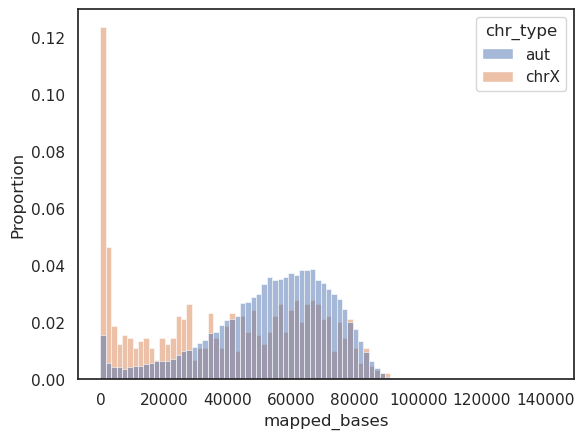

In [9]:
sns.histplot(all_pi_df.loc[all_pi_df.species == "Prolemur_simus_ssp"],
             x="mapped_bases", hue="chr_type", common_norm=False, stat="proportion")

<Axes: xlabel='mapped_bases', ylabel='Proportion'>

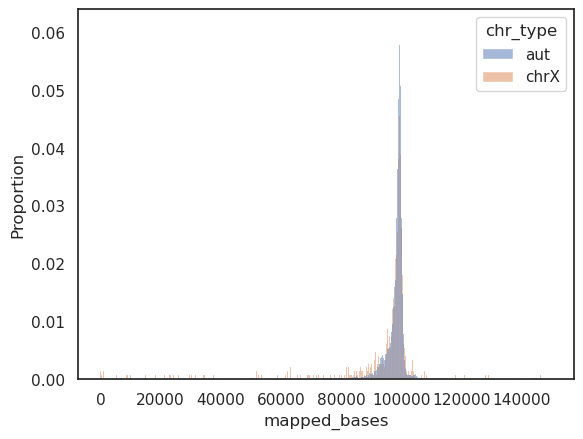

In [10]:
sns.histplot(all_pi_df.loc[(all_pi_df.species == "Gorilla_beringei_ssp") & (all_pi_df.mapped_bases <= 150000)],
             x="mapped_bases", hue="chr_type", common_norm=False, stat="proportion")

In [11]:
all_pi_df

,chrom,window_100kb,pi_window,mapped_bases,pi_per_mapped_base,genes,max_genes,largest_gene,largest_gene_cov,species,chr_type
0,NC_060925.1,0,220.560738,47016,0.004691,NaN,0,NaN,0.00000,Macaca_fascicularis_ssp,aut
1,NC_060925.1,100000,4.757545,1214,0.003919,['OR4F21'],0,OR4F21,0.00938,Macaca_fascicularis_ssp,aut
2,NC_060925.1,200000,212.822104,58860,0.003616,NaN,0,NaN,0.00000,Macaca_fascicularis_ssp,aut
3,NC_060925.1,300000,269.197770,63277,0.004254,['SAMD11' 'NOC2L' 'PLEKHN1' 'KLHL17'],0,SAMD11,0.17321,Macaca_fascicularis_ssp,aut
4,NC_060925.1,400000,237.559592,81586,0.002912,['AGRN' 'PERM1' 'PLEKHN1' 'HES4' 'ISG15'],0,AGRN,0.34747,Macaca_fascicularis_ssp,aut
...,...,...,...,...,...,...,...,...,...,...,...
28336,NC_060947.1,153800000,0.678400,60158,0.000011,['TMLHE'],0,TMLHE,0.94993,Semnopithecus_schistaceus_ssp,chrX
28337,NC_060947.1,153900000,0.258067,67648,0.000004,['SPRY3'],0,SPRY3,0.00867,Semnopithecus_schistaceus_ssp,chrX
28338,NC_060947.1,154000000,0.819000,48192,0.000017,NaN,0,NaN,0.00000,Semnopithecus_schistaceus_ssp,chrX
28339,NC_060947.1,154100000,1.534267,64030,0.000024,['VAMP7'],0,VAMP7,0.52682,Semnopithecus_schistaceus_ssp,chrX


In [12]:
count_callable_aut

NameError: name 'count_callable_aut' is not defined

In [ ]:
all_pi_df

In [ ]:
all_pi_df["Group"] = all_pi_df.species.map(dict(zip(metadata_20x_filt.species_genotyping, metadata_20x_filt.group)))
aut_pi = all_pi_df.loc[(all_pi_df.chr_type == "aut") & (~all_pi_df.pi_per_mapped_base.isna())]
chrX_pi = all_pi_df.loc[(all_pi_df.chr_type == "chrX") & (~all_pi_df.pi_per_mapped_base.isna())]
count_callable_chrX = chrX_pi.loc[chrX_pi.mapped_bases >= 50000].groupby(["species"])[["mapped_bases"]].count()
count_callable_aut = aut_pi.loc[aut_pi.mapped_bases >= 50000].groupby(["species"])[["mapped_bases"]].count()
group_list = count_callable_chrX.reset_index().species.map(dict(zip(metadata_20x_filt.species_genotyping, metadata_20x_filt.group)))
g = sns.scatterplot(x=count_callable_aut.mapped_bases, y=count_callable_chrX.mapped_bases, hue=list(group_list))
g.set(title="Relationship between mapped windows on autosomes and ChrX",
     xlabel="Autosomal windows above 50 % mapped bases", ylabel="ChrX windows above 50 % mapped bases")

Comparing reference and lifted versions.

In [ ]:
df_l = []
for s in metadata_20x_filt.species_genotyping.unique():
    f_c = len(metadata_20x_filt.loc[metadata_20x_filt.gSEX == "F"])
    if f_c == 0:
        continue
    # Read het df
    pi_df_path = "../results/window_stats_20x_inds/{}_100kb_pi.txt".format(s)
    if os.path.exists("../results/window_stats_20x_inds/{}_100kb_pi.txt".format(s)):
        pi_df = pd.read_csv(pi_df_path, sep="\t")
    else:
        print("Not present:", s)
        continue
    df_l.append(pi_df)
all_pi_df_ref = pd.concat(df_l)

In [ ]:
filt_pi_df = all_pi_df_ref.loc[all_pi_df_ref.callable_frac >= 0.5]
filt_pi_df["pi_adj"] = filt_pi_df.pi/filt_pi_df.callable_frac
mean_pi_df = filt_pi_df.loc[filt_pi_df.callable_frac >= 0.5].groupby(["species","chr_type"])[["pi", "pi_adj"]].mean()
mean_pi_df = mean_pi_df.reset_index().pivot(columns="chr_type", index="species", values="pi")
all_pi_df_aut = filt_pi_df.loc[filt_pi_df.chr_type == "aut"]
chrx_pi_df_aut = filt_pi_df.loc[filt_pi_df.chr_type == "chrX"]
mean_pi_df = mean_pi_df.reset_index()
mean_pi_df["CV_aut"] = (all_pi_df_aut.groupby(["species"])[["pi_adj"]].std() / all_pi_df_aut.groupby(["species"])[["pi_adj"]].mean()).reset_index()["pi_adj"]
CV_x_df = (chrx_pi_df_aut.groupby(["species"])[["pi_adj"]].std() / chrx_pi_df_aut.groupby(["species"])[["pi_adj"]].mean()).reset_index()
mean_pi_df["CV_x"] = mean_pi_df.species.map(dict(zip(CV_x_df.species, CV_x_df.pi_adj)))
mean_pi_df["Autosomal Pi per base"] = mean_pi_df.aut/100000
mean_pi_df["ChrX Pi per base"] = mean_pi_df.chrX/100000
mean_pi_df["X_a_ratio"] = mean_pi_df.chrX/mean_pi_df.aut
mean_pi_df["X/A ratio"] = mean_pi_df.chrX/mean_pi_df.aut

In [ ]:
mean_pi_df

In [ ]:
all_pi_df

In [ ]:
mean_pi_df_human = all_pi_df.loc[all_pi_df.mapped_bases >= 50000].groupby(["species","chr_type"])[["pi_per_mapped_base"]].mean()
mean_pi_df_human = mean_pi_df_human.reset_index().pivot(columns="chr_type", index="species", values="pi_per_mapped_base")
all_pi_df_aut_human = all_pi_df.loc[all_pi_df.chr_type == "aut"]
chrx_pi_df_aut_human = all_pi_df.loc[all_pi_df.chr_type == "chrX"]
mean_pi_df_human = mean_pi_df_human.reset_index()
mean_pi_df_human["Autosomal Pi per base"] = mean_pi_df_human.aut
mean_pi_df_human["ChrX Pi per base"] = mean_pi_df_human.chrX
mean_pi_df_human["X_a_ratio"] = mean_pi_df_human.chrX/mean_pi_df_human.aut
mean_pi_df_human["X/A ratio"] = mean_pi_df_human.chrX/mean_pi_df_human.aut

In [ ]:
mean_pi_df["human_X/A"] = mean_pi_df.species.map(dict(zip(mean_pi_df_human["species"],
                                                          mean_pi_df_human["X_a_ratio"])))
mean_pi_df["human_A"] = mean_pi_df.species.map(dict(zip(mean_pi_df_human["species"],
                                                          mean_pi_df_human["Autosomal Pi per base"])))
mean_pi_df["human_X"] = mean_pi_df.species.map(dict(zip(mean_pi_df_human["species"],
                                                          mean_pi_df_human["ChrX Pi per base"])))

In [ ]:
mean_pi_df

In [ ]:
g = sns.scatterplot(mean_pi_df, x="Autosomal Pi per base", y="human_A")
g.set(title="Autosomal Pi per base in reference and lift", xlabel="Autosomal Pi in reference",
      ylabel="Autosomal Pi in lifted coordinates")

In [ ]:
g = sns.scatterplot(mean_pi_df, x="ChrX Pi per base", y="human_X")
g.set(title="ChrX Pi per base in reference and lift", xlabel="ChrX Pi in reference",
      ylabel="ChrX Pi in lifted coordinates")

In [ ]:
mean_pi_df["Group"] = mean_pi_df.reset_index().species.map(dict(zip(metadata_20x_filt.species_genotyping, metadata_20x_filt.group)))
mean_pi_df["A_lift/A_ref"] = mean_pi_df["human_A"]/mean_pi_df["Autosomal Pi per base"]
g = sns.histplot(mean_pi_df, x="A_lift/A_ref", hue="Group", element="step")
g.set(xlabel = "Ratio of autosomal Pi between lift and reference")

In [ ]:
mean_pi_df["X_lift/X_ref"] = mean_pi_df["human_X"]/mean_pi_df["ChrX Pi per base"]
g = sns.histplot(mean_pi_df, x="X_lift/X_ref", hue="Group", element="step")
g.set(xlabel = "Ratio of chrX Pi between lift and reference")

In [ ]:
mean_pi_df[["Autosomal Pi per base", "human_A"]].corr()

In [ ]:
filt_windows = all_pi_df.loc[all_pi_df.mapped_bases >= 50000]
groups = filt_windows.groupby(["species", "chrom"])["pi_per_mapped_base"]
mean, std = groups.transform("mean"), groups.transform("std")
filt_windows["pi_norm"] = (filt_windows.pi_per_mapped_base-mean)/std
filt_windows

In [ ]:
filt_windows.loc[filt_windows.largest_gene == "SHOX"]

In [ ]:
mean_across_species = filt_windows.groupby(["chr_type", "chrom", "window_100kb"])["pi_norm"].mean().reset_index()
species_counted = filt_windows.groupby(["chr_type", "chrom", "window_100kb"])["pi_norm"].count().reset_index()
mean_across_species["species_used"] = species_counted["pi_norm"]

In [ ]:
sns.scatterplot(mean_across_species.loc[(mean_across_species.chr_type == "chrX") & (mean_across_species.species_used >= 50)],
               x="window_100kb", y="pi_norm")

In [ ]:
g = sns.scatterplot(mean_across_species.loc[(mean_across_species.chrom == 'NC_060927.1') & (mean_across_species.species_used >= 50)],
               x="window_100kb", y="pi_norm")
g.set(ylim=(None, 3))

In [ ]:
g = sns.scatterplot(mean_across_species.loc[(mean_across_species.chrom == 'NC_060930.1') & (mean_across_species.species_used >= 50)],
               x="window_100kb", y="pi_norm")
g.set(ylim=(None, 3))

In [ ]:
mean_across_species

In [ ]:
mean_across_species.loc[(mean_across_species.chr_type == "chrX")]#.species_used.min()

In [ ]:
sns.histplot(mean_across_species.loc[(mean_across_species.chr_type == "chrX")], x="species_used")